In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [21]:
base_path = "data/odometry"
sequence = "05"

# Load Left (image_0) for tracking, Right (image_1) for stereo depth
img_dir_left = os.path.join(base_path, sequence, "image_0")
img_dir_right = os.path.join(base_path, sequence, "image_1")
pose_file = os.path.join(base_path, sequence, f"{sequence}.txt")
calib_file = os.path.join(base_path, sequence, "calib.txt")

print(f"Reading sequence: {sequence}")
print(f"Images: {img_dir_left} - {img_dir_right}")
print(f"Poses:  {pose_file}")

Reading sequence: 05
Images: data/odometry/05/image_0 - data/odometry/05/image_1
Poses:  data/odometry/05/05.txt


In [9]:
def read_calib_stereo(filepath):
    """
    Reads P0 (Left) and P1 (Right) to get f, cx, cy, and Baseline B.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    P0 = np.array([float(x) for x in lines[0].split()[1:]]).reshape(3, 4)
    P1 = np.array([float(x) for x in lines[1].split()[1:]]).reshape(3, 4)
    
    # Decompose P0 to get K
    k = P0[:3, :3]
    f = k[0, 0]
    pp = (k[0, 2], k[1, 2])
    
    # Calculate Baseline B = -P1[0,3] / f (assuming rectified)
    # P1 is shifted along X relative to P0
    B = np.abs(P1[0, 3] / f)
    
    return pp, f, B

In [10]:
def read_poses(filepath):
    poses = []
    with open(filepath, 'r') as f:
        for line in f:
            T = np.fromstring(line, dtype=np.float64, sep=' ').reshape(3, 4)
            T_4x4 = np.eye(4)
            T_4x4[:3, :] = T
            poses.append(T_4x4)
    return poses

In [11]:
def compute_ate(gt_poses, est_poses):
    errors = []
    for i in range(len(est_poses)):
        gt_xyz = gt_poses[i][:3, 3]
        est_xyz = est_poses[i][:3, 3]
        dist = np.linalg.norm(gt_xyz - est_xyz)
        errors.append(dist**2)
    return np.sqrt(np.mean(errors))

In [12]:
def compute_stereo_ncc(img_left, img_right, window_size=5, max_disp=96):
    """
    NCC Implementation from Part A. 
    Reduced window_size and max_disp slightly for speed in VO loop.
    """
    h, w = img_left.shape
    
    # Pre-compute squares
    l_sq = img_left ** 2
    r_sq = img_right ** 2
    
    # Box filter for sums
    l_sum_sq = cv2.boxFilter(l_sq, -1, (window_size, window_size), normalize=False)
    
    best_cost = np.full((h, w), -1.0, dtype=np.float32)
    best_disp = np.zeros((h, w), dtype=np.float32)
    
    for d in range(max_disp):
        if d == 0:
            shifted_r = img_right
            shifted_r_sq = r_sq
        else:
            shifted_r = np.pad(img_right, ((0,0), (d,0)), mode='constant')[:, :-d]
            shifted_r_sq = np.pad(r_sq, ((0,0), (d,0)), mode='constant')[:, :-d]

        product = img_left * shifted_r
        num = cv2.boxFilter(product, -1, (window_size, window_size), normalize=False)
        
        r_sum_sq = cv2.boxFilter(shifted_r_sq, -1, (window_size, window_size), normalize=False)
        denom = np.sqrt(l_sum_sq * r_sum_sq) + 1e-10
        ncc = num / denom
        
        mask = ncc > best_cost
        best_cost[mask] = ncc[mask]
        best_disp[mask] = d
        
    return best_disp

In [22]:
images_left = sorted(os.listdir(img_dir_left))
images_right = sorted(os.listdir(img_dir_right))
gt_poses_all = read_poses(pose_file)
pp, f, B = read_calib_stereo(calib_file)

print(f"Camera Parameters: f={f:.2f}, B={B:.2f}, pp={pp}")

# Initialization
prev_img = None
prev_pts = None
prev_disp = None 

curr_R = np.eye(3)
curr_t = np.zeros((3, 1))

est_poses = []
gt_poses = []

num_frames = len(images_left) 
print(f"Processing {num_frames} frames...")

for i in range(num_frames):
    # Load Images
    imgL = cv2.imread(os.path.join(img_dir_left, images_left[i]), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    imgR = cv2.imread(os.path.join(img_dir_right, images_right[i]), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    
    # --- 1. Initialization (Frame 0) ---
    if i == 0:
        prev_img = imgL
        # Detect Features
        prev_pts = cv2.goodFeaturesToTrack(prev_img, maxCorners=2000, qualityLevel=0.01, minDistance=10)
        
        # Compute Initial Disparity (NCC)
        prev_disp = compute_stereo_ncc(imgL, imgR)
        
        T_init = np.eye(4)
        est_poses.append(T_init)
        gt_poses.append(gt_poses_all[0])
        continue

    # --- 2. Feature Tracking (Optical Flow) ---
    # Track points from (t-1) to (t)
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_img.astype(np.uint8), imgL.astype(np.uint8), prev_pts, None)
    
    # Filter valid tracks AND RESHAPE to (N, 2)
    status = status.flatten()
    good_prev = prev_pts[status == 1].reshape(-1, 2)
    good_curr = curr_pts[status == 1].reshape(-1, 2)
    
    # --- 3. Scale Recovery via Stereo (PnP) ---
    # We need 3D points at time (t-1) to estimate motion to (t)
    
    prev_pts_int = good_prev.astype(int)
    
    # Bounds check
    h, w = prev_disp.shape
    valid_indices = (prev_pts_int[:,1] >= 0) & (prev_pts_int[:,1] < h) & \
                    (prev_pts_int[:,0] >= 0) & (prev_pts_int[:,0] < w)
    
    good_prev = good_prev[valid_indices]
    good_curr = good_curr[valid_indices]
    prev_pts_int = prev_pts_int[valid_indices]
    
    # Extract disparities
    disparities = prev_disp[prev_pts_int[:, 1], prev_pts_int[:, 0]]
    
    # Filter out points with invalid disparity (<= 1.0 or too small)
    valid_disp_mask = disparities > 1.0
    
    # Check if we have enough points for PnP (need at least 4, ideally more)
    if np.sum(valid_disp_mask) < 10:
        # Fallback: assume no motion if tracking fails
        R, t = np.eye(3), np.zeros((3,1))
    else:
        # Final valid points
        q_prev = good_prev[valid_disp_mask] # 2D at t-1
        q_curr = good_curr[valid_disp_mask] # 2D at t
        d_vals = disparities[valid_disp_mask]
        
        # Reconstruct 3D points in (t-1) coordinate system
        Z = (f * B) / d_vals
        X = (q_prev[:, 0] - pp[0]) * Z / f
        Y = (q_prev[:, 1] - pp[1]) * Z / f
        
        object_points = np.stack([X, Y, Z], axis=1) # Shape (N, 3)
        
        # Solve PnP: Find pose that maps 3D points (at t-1) to 2D pixels (at t)
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            object_points, 
            q_curr, 
            np.array([[f, 0, pp[0]], [0, f, pp[1]], [0, 0, 1]]), 
            None,
            iterationsCount=100,
            reprojectionError=1.0
        )
        
        if success:
            R, _ = cv2.Rodrigues(rvec)
            t = tvec
            
            # Invert PnP result to get Camera Motion
            # PnP gives T_{t-1 -> t} (World to Camera)
            # We want to accumulate the camera's position in the global frame
            R_inv = R.T
            t_inv = -R_inv @ t
            
            curr_t = curr_t + curr_R.dot(t_inv)
            curr_R = curr_R.dot(R_inv)

    # --- 4. Save & Update ---
    T_est = np.eye(4)
    T_est[:3, :3] = curr_R
    T_est[:3, 3] = curr_t.flatten()
    
    est_poses.append(T_est)
    gt_poses.append(gt_poses_all[i])
    
    # Prepare for next iteration
    prev_img = imgL
    
    # Re-detect features if too few
    if len(good_curr) < 1000:
        prev_pts = cv2.goodFeaturesToTrack(prev_img.astype(np.uint8), maxCorners=2000, qualityLevel=0.01, minDistance=10)
    else:
        # Reshape back to (N, 1, 2) for next Optical Flow iteration
        prev_pts = good_curr.reshape(-1, 1, 2)
        
    # Compute disparity for the NEW frame
    prev_disp = compute_stereo_ncc(imgL, imgR)

    if i % 20 == 0:
        print(f"Frame {i}/{num_frames} | Pose X: {curr_t[0][0]:.2f} Z: {curr_t[2][0]:.2f}")

Camera Parameters: f=707.09, B=0.54, pp=(np.float64(601.8873), np.float64(183.1104))
Processing 2761 frames...
Frame 20/2761 | Pose X: -0.32 Z: 12.63
Frame 40/2761 | Pose X: -0.84 Z: 30.97
Frame 60/2761 | Pose X: -1.53 Z: 52.43
Frame 80/2761 | Pose X: -2.24 Z: 74.33
Frame 100/2761 | Pose X: -3.11 Z: 94.57
Frame 120/2761 | Pose X: -3.60 Z: 105.99
Frame 140/2761 | Pose X: 0.51 Z: 111.74
Frame 160/2761 | Pose X: 10.60 Z: 112.39
Frame 180/2761 | Pose X: 26.61 Z: 111.96
Frame 200/2761 | Pose X: 42.64 Z: 111.30
Frame 220/2761 | Pose X: 56.44 Z: 110.41
Frame 240/2761 | Pose X: 71.07 Z: 108.69
Frame 260/2761 | Pose X: 87.14 Z: 106.47
Frame 280/2761 | Pose X: 104.14 Z: 104.35
Frame 300/2761 | Pose X: 119.65 Z: 102.03
Frame 320/2761 | Pose X: 133.80 Z: 98.46
Frame 340/2761 | Pose X: 146.32 Z: 94.79
Frame 360/2761 | Pose X: 157.49 Z: 93.68
Frame 380/2761 | Pose X: 167.34 Z: 91.59
Frame 400/2761 | Pose X: 178.03 Z: 88.20
Frame 420/2761 | Pose X: 186.81 Z: 86.45
Frame 440/2761 | Pose X: 193.97 Z: 9


=== EVALUATION REPORT ===
ATE (RMSE): 12.2430 meters


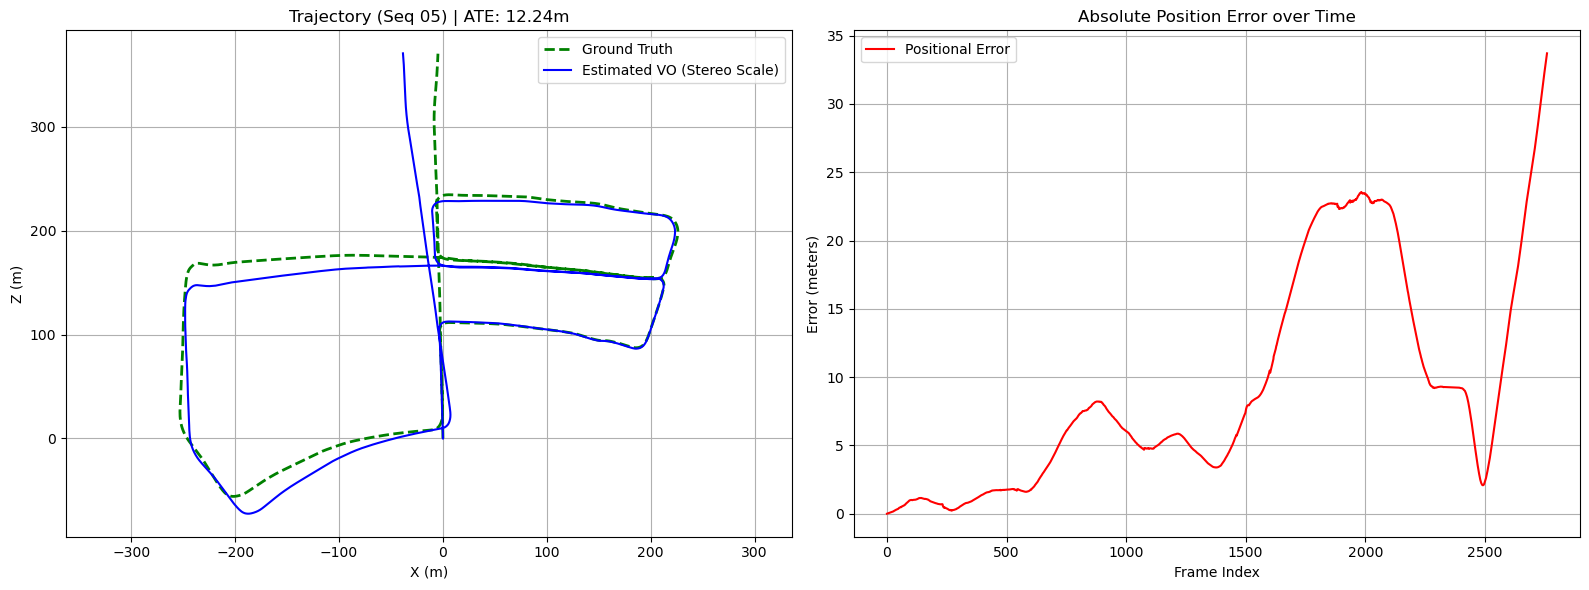

In [23]:
print("\n=== EVALUATION REPORT ===")

ate = compute_ate(gt_poses, est_poses)
print(f"ATE (RMSE): {ate:.4f} meters")

# Prepare Data for Plotting
gt_x = [p[0, 3] for p in gt_poses]
gt_z = [p[2, 3] for p in gt_poses]
est_x = [p[0, 3] for p in est_poses]
est_z = [p[2, 3] for p in est_poses]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Trajectory Map
axes[0].plot(gt_x, gt_z, 'g--', label='Ground Truth', linewidth=2)
axes[0].plot(est_x, est_z, 'b', label='Estimated VO (Stereo Scale)', linewidth=1.5)
axes[0].set_title(f"Trajectory (Seq {sequence}) | ATE: {ate:.2f}m")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Z (m)")
axes[0].legend()
axes[0].axis('equal')
axes[0].grid()

# Plot B: Error over time
errors = [np.linalg.norm(est_poses[i][:3,3] - gt_poses[i][:3,3]) for i in range(len(est_poses))]
axes[1].plot(errors, 'r', label='Positional Error')
axes[1].set_title("Absolute Position Error over Time")
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Error (meters)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(f"figures/eval_report.png")
plt.show()